# **DATA MODELLING**


## UNSUPERVISED LEARNING - Clustering


Lets look at a very simple example of unsupervised learning.

###1. Load and Explore the data


1.1 Load the penguis dataset from seaborn.


In [1]:
# import
import seaborn as sns

# Load the dataset
df = sns.load_dataset("penguins")

1.2 Look at the raw data.


In [2]:
# Display head of the data
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


1.3 Visualise the data using a [3D scatter plot](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html).
Select three suitable variables to plot.


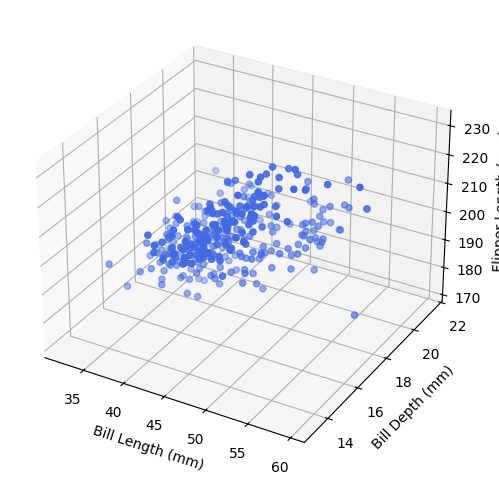

In [3]:
#Import the relevant libraries
import matplotlib.pyplot as plt

# Select three suitable numerical variables from the penguins dataset
x = df['bill_length_mm']
y = df['bill_depth_mm']
z = df['flipper_length_mm']

# Create figure and 3D axes
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D scatter
ax.scatter(x, y, z, color='royalblue', marker='o')

# Add labels
ax.set_xlabel('Bill Length (mm)')
ax.set_ylabel('Bill Depth (mm)')
ax.set_zlabel('Flipper Length (mm)')

plt.show()

###2. Data Processing - part 1


2.1 Identify the catagorical columns (https://medium.com/@fathima.nusra.thameem/how-to-find-categorical-columns-in-your-pandas-dataframe-e7553feef62e) and put them in a list.

Hint: look for 'catagory' AND 'object'.


In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['species', 'island', 'sex']


2.2 Encode categorical variables 'island', 'species' and 'sex' using [LabelEncoder](https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/).


In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0        0       2            39.1           18.7              181.0   
1        0       2            39.5           17.4              186.0   
2        0       2            40.3           18.0              195.0   
3        0       2             NaN            NaN                NaN   
4        0       2            36.7           19.3              193.0   

   body_mass_g  sex  
0       3750.0    1  
1       3800.0    0  
2       3250.0    0  
3          NaN    2  
4       3450.0    0  


###3. Exploratory Data Analysis
Here we have a simple dataset, but what would you do if it was more complicated? EDA!

Let's use pairplots and 3D scatter plots to do some EDA...


3.1 Lets start with the seaborn [Pair plot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).


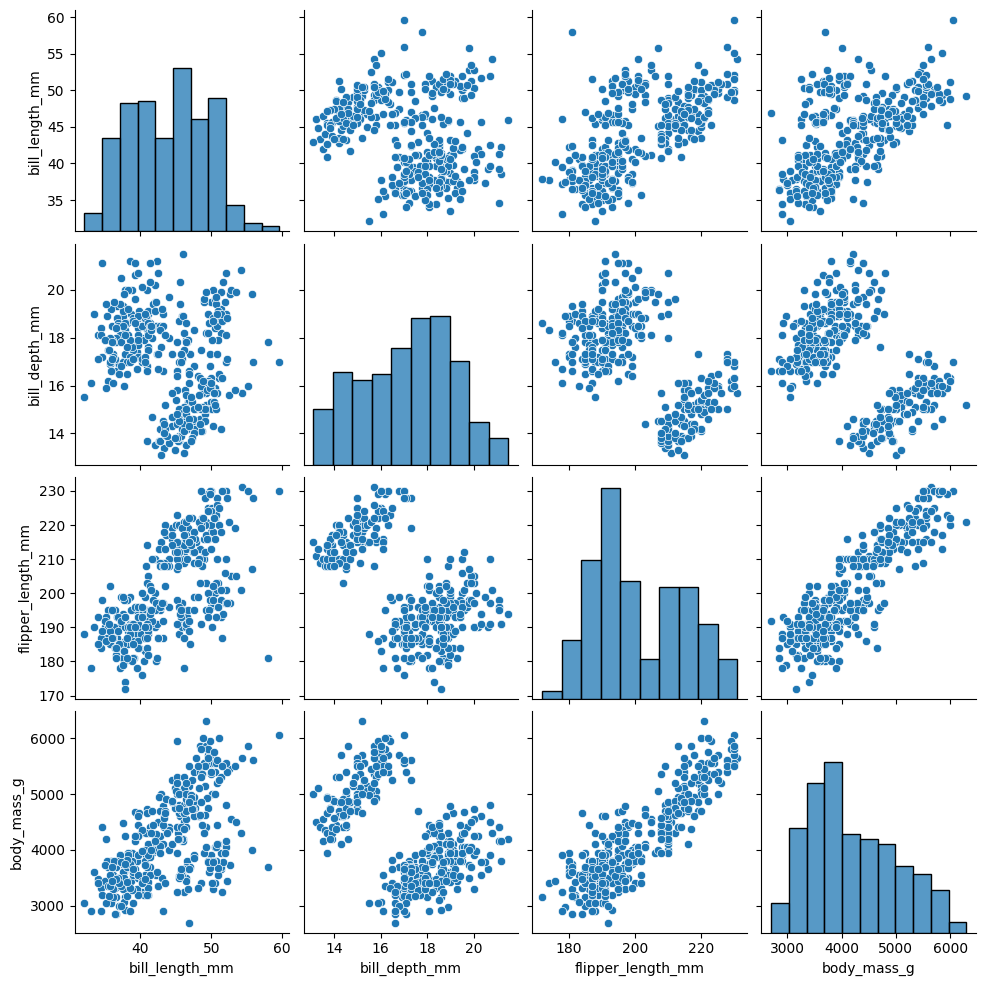

In [12]:
penguins = sns.load_dataset("penguins")
sns.pairplot(penguins)

3.2 Let's recreate the earlier [3D scatter plot](https://machinelearningmastery.com/data-visualization-in-python-with-matplotlib-seaborn-and-bokeh/) but add the species as the hue (c).


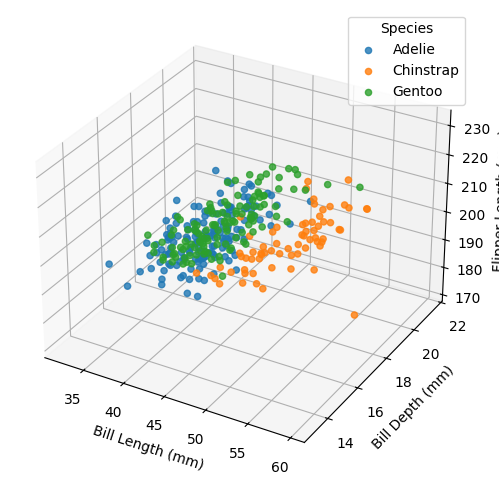

In [13]:
# 3D scatter with species as hue
df_plot = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species'])
species_unique = df_plot['species'].unique()
palette = sns.color_palette(n_colors=len(species_unique))

fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')

for i, sp in enumerate(species_unique):
    sel = df_plot['species'] == sp
    ax2.scatter(
        df_plot.loc[sel, 'bill_length_mm'],
        df_plot.loc[sel, 'bill_depth_mm'],
        df_plot.loc[sel, 'flipper_length_mm'],
        label=sp,
        color=palette[i],
        alpha=0.8
    )

ax2.set_xlabel('Bill Length (mm)')
ax2.set_ylabel('Bill Depth (mm)')
ax2.set_zlabel('Flipper Length (mm)')
ax2.legend(title='Species')
plt.show()

### 4. Data Processing - part 2


4.1 Remove the catagorical columns - It makes no sense to do clustering if we include the catagorical data. Let's see if we will still have the expected 3 clusters without it.

4.2 Remove the records with missing nans,

4.3 randomise the data and

4.4 convert to array.


In [20]:
import numpy as np

df_cleaned = df.dropna()


df_cleaned = df_cleaned.sample(frac=1, random_state=0)

df_cleaned = df_cleaned.drop(columns=categorical_cols, errors="ignore")


X = df_cleaned.to_numpy()

print(df_cleaned.head())
print(X.shape)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
93             39.6           18.1              186.0       4450.0
281            46.2           14.9              221.0       5300.0
133            37.5           18.5              199.0       4475.0
280            45.3           13.8              208.0       4200.0
7              39.2           19.6              195.0       4675.0
(342, 4)


### 5. Clustering

Clearly clustering would be an ideal solution, so lets try the K=means method.

Look at the documentation for the **python library "sklearn kmeans clustering"** for what the algorithm requires.


From the documentation the only input the algorithm requires is the number of clusters (k).
It should be noted that while a random state is not required, it would be a good idea to set it for reproducablilty, we can just choose 0.


5.1 Determine number of clusters.


The way to determine the optimal number of clusters is to use the **elbow method**. More information on how to impliment this method can be obtained by looking at the documentation for the elbow method in the python library yellowbrick by searching something like **"yellowbrick elbow method"**.

Follow the instructions and impliment the elbow method to determine the optimal number of clusters.


Determine where the elbow 'bends' (blue line) to the largest degree or the most obviously.

NOTE: if the data in not suitable for clustering, the method wont work well or even at all.


5.2 Run the model.

Next, we implement the kmeans clusterning using the instructions in the sklearn kmeans documentation and fit the model to the data. (Because it's unsupervised ther is no train/test split or target varaible).


5.3 Display the predicted cluster centers.

Lest see where the identified cluster centers are located using a print statement.


5.4 Visualising cluster centers on data.

Finally lets visualise the previous 3D plot, but now also include the cluster centers on the plot. (**HINT**: use a scatterplot with markers and count in what columns the features that you are plotting are. E.g body_mass was in column 5.)
